# Module 7 — 最小平方與資料擬合

> **對應程度**：大學線代應用 + 初等統計

## 為什麼工程師需要最小平方法？

在工程實務中，我們經常面對這樣的情境：手邊有一堆實驗量測數據，需要從中找出隱藏的物理規律。例如：

- 你在實驗室拉伸彈簧，量了 30 組力與位移的數據，想找出彈簧常數 $k$
- 你校正一支熱電偶，量了 50 組溫度與電壓的對應，想建立轉換公式
- 你在風洞中測試車體模型，量了不同風速下的阻力，想算出阻力係數

這些問題的共通點是：**數據有雜訊（noise），而且數據點比未知數多很多**。我們不可能找到一條完美通過所有點的曲線，但我們可以找到「最接近」所有數據的那條曲線。這就是**最小平方法（Least Squares）**的核心思想。

### 原理概述

最小平方法的目標很直觀：**找到一組參數，使得模型預測值與實際量測值之間的「總誤差」最小**。這裡的「總誤差」定義為所有殘差（residual）的平方和：

$$\min_{\vec{\beta}} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \min_{\vec{\beta}} \|X\vec{\beta} - \vec{y}\|^2$$

為什麼用「平方」而不是「絕對值」？因為平方函數是可微分的，讓我們可以用微積分找到精確解；而且平方會更嚴厲地懲罰大的偏差，這在工程上通常是合理的——一個巨大的預測錯誤比很多小錯誤更危險。

### 直覺理解

想像你在一片草地上立了 30 根竹竿（代表數據點），你要用一條繩子（代表擬合線）穿過這些竹竿的「附近」。最小平方法就是找到繩子的最佳位置，使得每根竹竿到繩子的垂直距離的平方總和最小。

### 本模組涵蓋

1. **線性迴歸的矩陣解**（Normal Equation）— 一行公式搞定擬合
2. **多項式擬合** — 用高次曲線捕捉非線性關係
3. **正規化（Regularization）** — 當問題「病態」時如何穩定求解

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.linalg_utils import least_squares_normal, ridge_regression
from src.datasets import generate_spring_data, generate_thermocouple_data, generate_drag_data
from src.visualizer import set_style

set_style()
print('Module 7 載入完成！')

Module 7 載入完成！


---
## 7.1 線性迴歸的矩陣解

### 原理：Normal Equation（正規方程式）

當我們要最小化 $\|X\vec{\beta} - \vec{y}\|^2$ 時，對 $\vec{\beta}$ 微分並令其為零，可以推導出著名的**正規方程式（Normal Equation）**：

$$\hat{\beta} = (X^TX)^{-1}X^T\vec{y}$$

這個公式的每一部分都有清楚的意義：
- $X$ 是**設計矩陣（design matrix）**：每一列是一筆數據，每一欄是一個特徵（feature）
- $X^TX$ 是特徵之間的「內積矩陣」，捕捉了特徵間的相關性
- $X^T\vec{y}$ 是特徵與目標值之間的相關性
- $(X^TX)^{-1}$ 把特徵間的相關性「解耦」，讓我們得到每個特徵的獨立貢獻

### 直覺理解：幾何投影

從幾何角度看，Normal Equation 其實在做**向量投影**。想像三維空間中，$\vec{y}$（量測向量）是一個指向任意方向的向量，而 $X$ 的行空間（column space）是一個平面。我們要找的 $X\hat{\beta}$ 就是 $\vec{y}$ 在這個平面上的**正交投影**——也就是平面上離 $\vec{y}$ 最近的那個點。

就像你站在一座高塔上，地面是一個平面。你的影子（投影）就是地面上離你最近的點。Normal Equation 做的就是找到數據的「影子」落在模型空間中的哪個位置。

殘差向量 $\vec{e} = \vec{y} - X\hat{\beta}$ 垂直於 $X$ 的行空間，這就是為什麼正規方程式要求 $X^T\vec{e} = 0$（殘差與每個特徵正交）。

### $R^2$（判定係數）：模型好不好？

$R^2$ 是評估模型擬合品質最常用的指標：

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- $R^2 = 1$：模型完美解釋所有數據變異（每個預測值都等於量測值）
- $R^2 = 0$：模型和直接用平均值預測一樣糟（沒有解釋任何變異）
- $R^2 = 0.95$：模型解釋了 95% 的數據變異，只剩 5% 是無法解釋的雜訊

直覺上，$R^2$ 回答的問題是：**「我的模型比『不管輸入是什麼都猜平均值』好多少？」**

### 為什麼重要？

Normal Equation 是工程數據分析的基石。從材料測試（應力-應變關係）、感測器校正（電壓-物理量轉換）到系統識別（輸入-輸出模型），幾乎所有需要「從數據找規律」的工程問題都可以歸結為某種形式的最小平方問題。掌握矩陣解法，你就能用一行程式碼解決這些問題。

---

### 範例 1：彈簧常數擬合 — 虎克定律 $F = kx$

**物理背景：** 虎克定律（Hooke's Law）描述彈簧的力與位移之間的線性關係：$F = kx$，其中 $k$ 是彈簧常數（單位：N/m），$x$ 是彈簧的伸長量。$k$ 值越大，彈簧越硬。

**實驗情境：** 假設你在材料力學實驗室中，用砝碼對一根彈簧施加不同的力，並用尺量測對應的伸長量。由於量測工具的精度有限（尺的最小刻度、讀數的視差誤差等），每次量測都會有些許雜訊。你量了 30 組 $(x, F)$ 數據，想從中估計出最精確的 $k$ 值。

**為什麼需要擬合？** 如果沒有雜訊，任意一組 $(x, F)$ 就能算出 $k = F/x$。但有雜訊時，每組數據算出的 $k$ 都略有不同。最小平方法綜合所有 30 組數據，找出「最佳」的 $k$ 值，比任何單一量測都更準確。這就是**以量取勝**的策略。

真實彈簧常數: k = 150.0 N/m
擬合彈簧常數: k = 153.03 N/m
R² = 0.907698
RMSE = 1.5176 N


/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/25405079.py:35: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/25405079.py:35: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/25405079.py:35: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/25405079.py:35: UserWarning: Glyph 24392 (\N{CJK UNIFIED IDEOGRAPH-5F48}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/25405079.py:35: UserWarning: Glyph 31783 (\N{CJK UNIFIED IDEOGRAPH-7C27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7

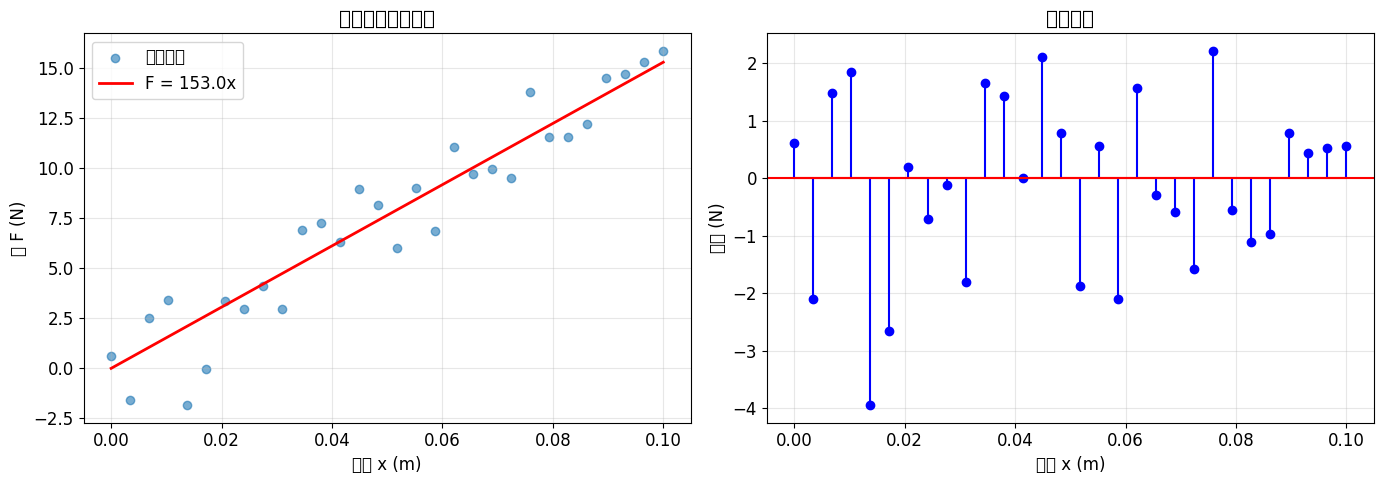

In [2]:
# 彈簧力-位移數據
x_data, F_data, true_k = generate_spring_data(n_points=30, true_k=150.0, noise_std=2.0)

# 設計矩陣 (無截距: F = kx)
X = x_data.reshape(-1, 1)
k_fit = least_squares_normal(X, F_data)

# R² 計算
F_pred = X @ k_fit
SS_res = np.sum((F_data - F_pred) ** 2)
SS_tot = np.sum((F_data - np.mean(F_data)) ** 2)
R2 = 1 - SS_res / SS_tot

print(f'真實彈簧常數: k = {true_k} N/m')
print(f'擬合彈簧常數: k = {k_fit[0]:.2f} N/m')
print(f'R² = {R2:.6f}')
print(f'RMSE = {np.sqrt(np.mean((F_data - F_pred)**2)):.4f} N')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_fit = np.linspace(0, x_data.max(), 100)
ax1.scatter(x_data, F_data, alpha=0.6, label='實驗數據')
ax1.plot(x_fit, k_fit[0] * x_fit, 'r-', lw=2, label=f'F = {k_fit[0]:.1f}x')
ax1.set_xlabel('位移 x (m)')
ax1.set_ylabel('力 F (N)')
ax1.set_title('彈簧常數線性擬合')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.stem(x_data, F_data - F_pred.flatten(), linefmt='b-', markerfmt='bo', basefmt='r-')
ax2.axhline(0, color='r')
ax2.set_xlabel('位移 x (m)')
ax2.set_ylabel('殘差 (N)')
ax2.set_title('殘差分佈')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 範例 2：熱電偶特性曲線 — 多項式擬合

**什麼是熱電偶？** 熱電偶（thermocouple）是工業界最常用的溫度感測器之一。它的原理很簡單：把兩種不同的金屬線（例如鉻鎳合金和鋁鎳合金，即 K 型熱電偶）的一端焊接在一起，當焊接點的溫度改變時，另一端會產生微小的電壓差（稱為 Seebeck 效應）。量測這個電壓，就能推算溫度。

**為什麼需要多項式擬合？** 理論上，熱電偶的電壓-溫度關係不是完美的直線，而是一條微彎的曲線。在窄溫度範圍（例如 20°C~100°C），線性近似就夠好了；但在寬範圍（例如 0°C~1000°C），你需要用 2 次甚至 3 次多項式來精確描述這條曲線：

$$V(T) = a_0 + a_1 T + a_2 T^2 + a_3 T^3$$

**設計矩陣的構造：** 多項式擬合仍然是「線性」迴歸！因為模型對**參數** $(a_0, a_1, a_2, a_3)$ 是線性的。設計矩陣為：

$$X = \begin{bmatrix} 1 & T_1 & T_1^2 & T_1^3 \\ 1 & T_2 & T_2^2 & T_2^3 \\ \vdots & \vdots & \vdots & \vdots \\ 1 & T_n & T_n^2 & T_n^3 \end{bmatrix}$$

這就是所謂的 **Vandermonde 矩陣**。每增加一個多項式次數，設計矩陣就多一欄。

**工程意義：** 熱電偶校正是每個溫度量測系統的基礎。好的校正多項式直接決定了你的溫度量測精度。在航太、核能、半導體製程等領域，溫度量測精度要求可達 $\pm 0.1°C$，這時多項式擬合的品質至關重要。

1次: 係數 = [-0.200675  0.041006], RMSE = 0.003744
2次: 係數 = [-0.201097  0.041012 -0.      ], RMSE = 0.003739
3次: 係數 = [-0.201683  0.041031 -0.        0.      ], RMSE = 0.003730


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22739 (\N{CJK UNIFIED IDEOGRAPH-58D3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29105 (\N{CJK UNIFIED IDEOGRAPH-71B1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20598 (\N{CJK UNIFIED IDEOGRAPH-5076}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

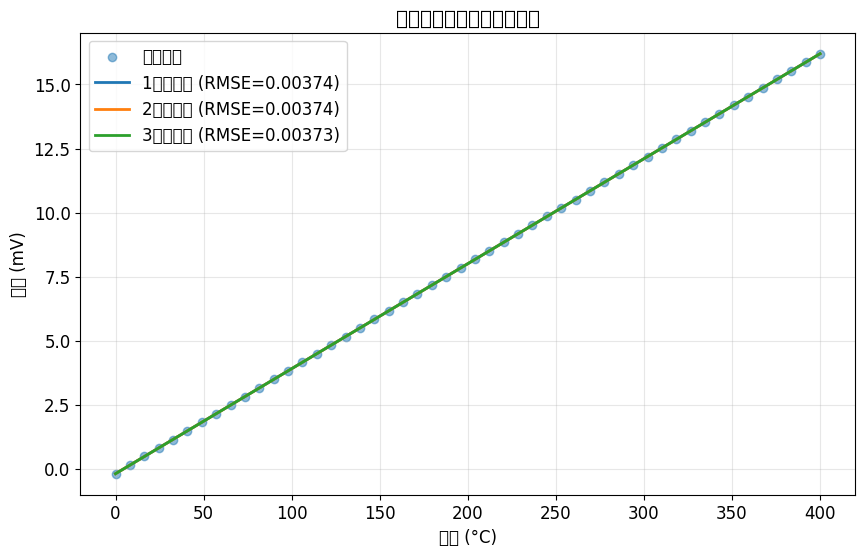

In [3]:
# 熱電偶多項式擬合
T_data, V_data, true_params = generate_thermocouple_data(n_points=50)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(T_data, V_data, alpha=0.5, label='量測數據')

for degree in [1, 2, 3]:
    # 建立設計矩陣
    X_poly = np.column_stack([T_data**i for i in range(degree + 1)])
    beta = least_squares_normal(X_poly, V_data)

    T_fit = np.linspace(T_data.min(), T_data.max(), 200)
    X_fit = np.column_stack([T_fit**i for i in range(degree + 1)])
    V_fit = X_fit @ beta

    V_pred = X_poly @ beta
    rmse = np.sqrt(np.mean((V_data - V_pred)**2))
    ax.plot(T_fit, V_fit, lw=2, label=f'{degree}次多項式 (RMSE={rmse:.5f})')
    print(f'{degree}次: 係數 = {np.round(beta, 6)}, RMSE = {rmse:.6f}')

ax.set_xlabel('溫度 (°C)')
ax.set_ylabel('電壓 (mV)')
ax.set_title('熱電偶特性曲線多項式擬合')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 範例 3：空氣阻力係數識別 — 風洞測試

**物理背景：** 當物體在空氣中移動時，會受到空氣阻力。阻力的大小由以下公式描述：

$$F_d = \frac{1}{2} \rho C_d A v^2$$

其中各參數的意義為：
- $\rho$：空氣密度（海平面約 $1.225 \text{ kg/m}^3$）
- $C_d$：阻力係數（drag coefficient），無因次數，取決於物體的形狀。流線型跑車約 0.25~0.35，SUV 約 0.35~0.45，方形貨車約 0.6~0.8
- $A$：物體正面投影面積（frontal area），也就是物體「迎風面」的大小
- $v$：物體相對於空氣的速度

**風洞測試：** 在汽車或飛機設計中，工程師會製作縮比模型放入風洞中，在不同風速下量測阻力。風洞可以精確控制風速，而天平（force balance）可以精確量測力，但仍有量測雜訊。

**線性化技巧：** 雖然阻力與速度的關係是二次的（$F_d \propto v^2$），但如果我們令 $u = v^2$，則 $F_d = c \cdot u$ 就變成了線性問題！其中 $c = \frac{1}{2}\rho C_d A$。擬合出 $c$ 後，就能反推 $C_d \cdot A$ 的值。

**直覺理解：** 為什麼阻力與速度的平方成正比？想像你把手伸出車窗外——車開 60 km/h 時，手上感受到的風壓不是 30 km/h 時的兩倍，而是四倍。這是因為速度加倍時，單位時間撞到你手上的空氣分子數量加倍，而且每個分子的動量也加倍，所以效果是 $2 \times 2 = 4$ 倍。

**為什麼重要？** $C_d$ 值直接影響車輛的燃油效率。以時速 100 km/h 巡航的轎車，約 60% 的引擎動力用於克服空氣阻力。$C_d$ 每降低 0.01，燃油效率可提升約 0.3~0.5%。因此，精確測定 $C_d$ 是汽車空氣動力學設計的核心工作。

真實 Cd*A = 0.5
估計 Cd*A = 0.5001


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38459 (\N{CJK UNIFIED IDEOGRAPH-963B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27683 (\N{CJK UNIFIED IDEOGRAPH-6C23}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20418 (\N{CJK UNIFIED IDEOGRAPH-4FC2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

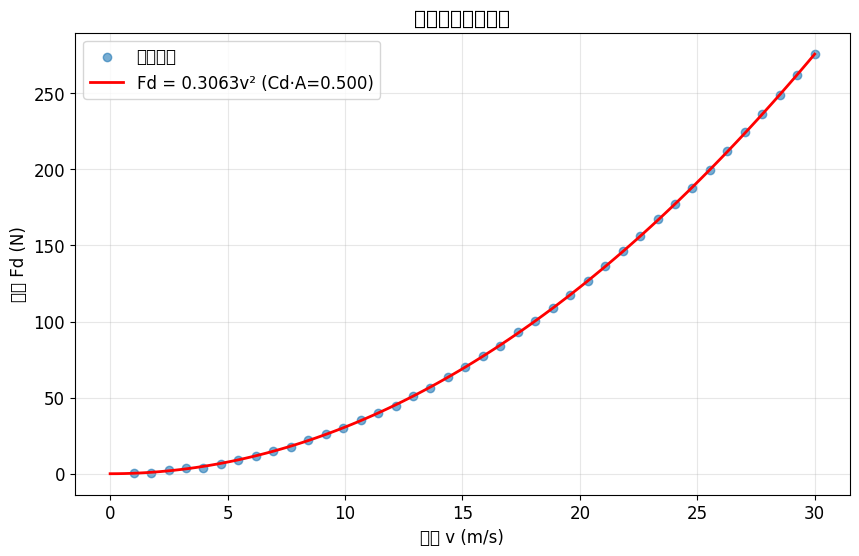

In [4]:
# 空氣阻力參數識別: Fd = 0.5 * rho * Cd_A * v^2
v_data, Fd_data, drag_params = generate_drag_data()

# 線性化: Fd = c * v^2, 其中 c = 0.5 * rho * Cd_A
X_drag = (v_data ** 2).reshape(-1, 1)
c_fit = least_squares_normal(X_drag, Fd_data)
Cd_A_est = c_fit[0] / (0.5 * drag_params['rho'])

print(f'真實 Cd*A = {drag_params["Cd_A"]}')
print(f'估計 Cd*A = {Cd_A_est:.4f}')

v_fit = np.linspace(0, v_data.max(), 100)
Fd_fit = c_fit[0] * v_fit**2

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(v_data, Fd_data, alpha=0.6, label='風洞數據')
ax.plot(v_fit, Fd_fit, 'r-', lw=2,
        label=f'Fd = {c_fit[0]:.4f}v² (Cd·A={Cd_A_est:.3f})')
ax.set_xlabel('速度 v (m/s)')
ax.set_ylabel('阻力 Fd (N)')
ax.set_title('空氣阻力係數識別')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

---
## 7.2 正規化（Regularization）

### 原理：當最小平方法「失靈」的時候

在 7.1 中，我們假設 $X^TX$ 是可逆的，所以可以直接套用 Normal Equation。但在某些問題中，$X^TX$ 的條件數（condition number）非常大，這意味著矩陣「幾乎奇異」——我們稱之為**病態問題（ill-conditioned problem）**。

病態問題的症狀是：**量測數據中一點點微小的雜訊，會導致求解結果產生巨大的、不合理的震盪**。數學上，如果 $A$ 的條件數是 $10^{10}$，那麼數據中 $10^{-3}$ 量級的雜訊會被放大到 $10^{7}$ 量級——完全無法使用。

### 直覺理解：模糊拼圖的比喻

想像你在拼一幅拼圖，但每片拼圖都被磨得很模糊。如果你硬要拼出一幅「完美清晰」的圖案，你會不自覺地在模糊的地方腦補出奇怪的細節——這些細節可能完全不對。

正規化的做法是：**我接受拼出來的圖案不會完美吻合每一片拼圖，但我要求圖案整體要「平滑合理」**。這就是在「吻合數據」與「解的合理性」之間取得平衡。

### Ridge Regression（嶺迴歸）公式

Ridge Regression 在原本的最小平方目標函數中加入一個**懲罰項**：

$$\min_{\vec{x}} \|A\vec{x} - \vec{b}\|^2 + \lambda\|\vec{x}\|^2$$

其中 $\lambda > 0$ 是正規化參數。這個公式的封閉解為：

$$\hat{x} = (A^TA + \lambda I)^{-1}A^T\vec{b}$$

**為什麼加 $\lambda I$ 有用？** 回想條件數的定義：$\kappa(A) = \sigma_{max}/\sigma_{min}$。當 $\sigma_{min}$ 很小（矩陣接近奇異）時，條件數爆大。加上 $\lambda I$ 之後，最小奇異值從 $\sigma_{min}$ 變成 $\sqrt{\sigma_{min}^2 + \lambda}$，有效地「墊高」了矩陣的底部，讓條件數降低，解就不會發散了。

代價是什麼？$\lambda$ 越大，解越穩定（越平滑），但也越偏離真實值（因為我們不再完美擬合數據）。這就引出了一個核心問題：**如何選擇最佳的 $\lambda$？**

### 為什麼重要？

病態問題在工程中非常常見：
- **逆向熱傳導**：從表面溫度量測推算內部熱源分佈
- **影像重建**：CT 掃描、MRI 從投影數據重建三維影像
- **結構健康監測**：從振動響應推算結構的損傷位置
- **地球物理勘探**：從地表量測推算地下的岩層結構

這些問題的共通點是：我們要從**結果**（量測到的東西）反推**原因**（想知道的東西），而這個反推過程天生就是病態的。正規化是解決這類問題的關鍵技術。

---

### 範例：逆向熱傳導問題

**物理情境：** 假設有一根金屬棒，內部有未知的熱源分佈 $q(x)$。我們只能在金屬棒的表面量測溫度 $T_{surface}$。物理告訴我們，表面溫度是內部熱源經過熱傳導「擴散」後的結果。數學上，這個擴散過程可以用一個核函數（kernel）矩陣 $A$ 來描述：

$$\vec{T}_{surface} = A \vec{q} + \text{noise}$$

問題是：已知 $\vec{T}_{surface}$（量測值）和 $A$（物理模型），求 $\vec{q}$（熱源）。

**為什麼病態？** 熱傳導是一個「平滑化」的過程——不管內部熱源有多尖銳的變化，經過擴散後，表面溫度都變得很平滑。這意味著 $A$ 矩陣會「抹平」$\vec{q}$ 中的細節。反過來求解時，任何微小的量測雜訊都會被放大成巨大的震盪，因為解算器會試圖「還原」那些已經被抹平的細節。

矩陣條件數: 8.3e+16 (非常病態！)
直接求解: max|q| = 9.8e+12 (嚴重發散！)


/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:314: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.solve(A.T @ A + lam * np.eye(n), A.T @ b)
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:314: RuntimeWarning: overflow encountered in matmul
  return np.linalg.solve(A.T @ A + lam * np.eye(n), A.T @ b)
/Users/rexwang/workspace/engineering-linalg-tutorial/notebooks/../src/linalg_utils.py:314: RuntimeWarning: invalid value encountered in matmul
  return np.linalg.solve(A.T @ A + lam * np.eye(n), A.T @ b)
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/3349801733.py:47: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/3349801733.py:47: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27714 (\N{CJK UNIFIED IDEOGRAPH-6C42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

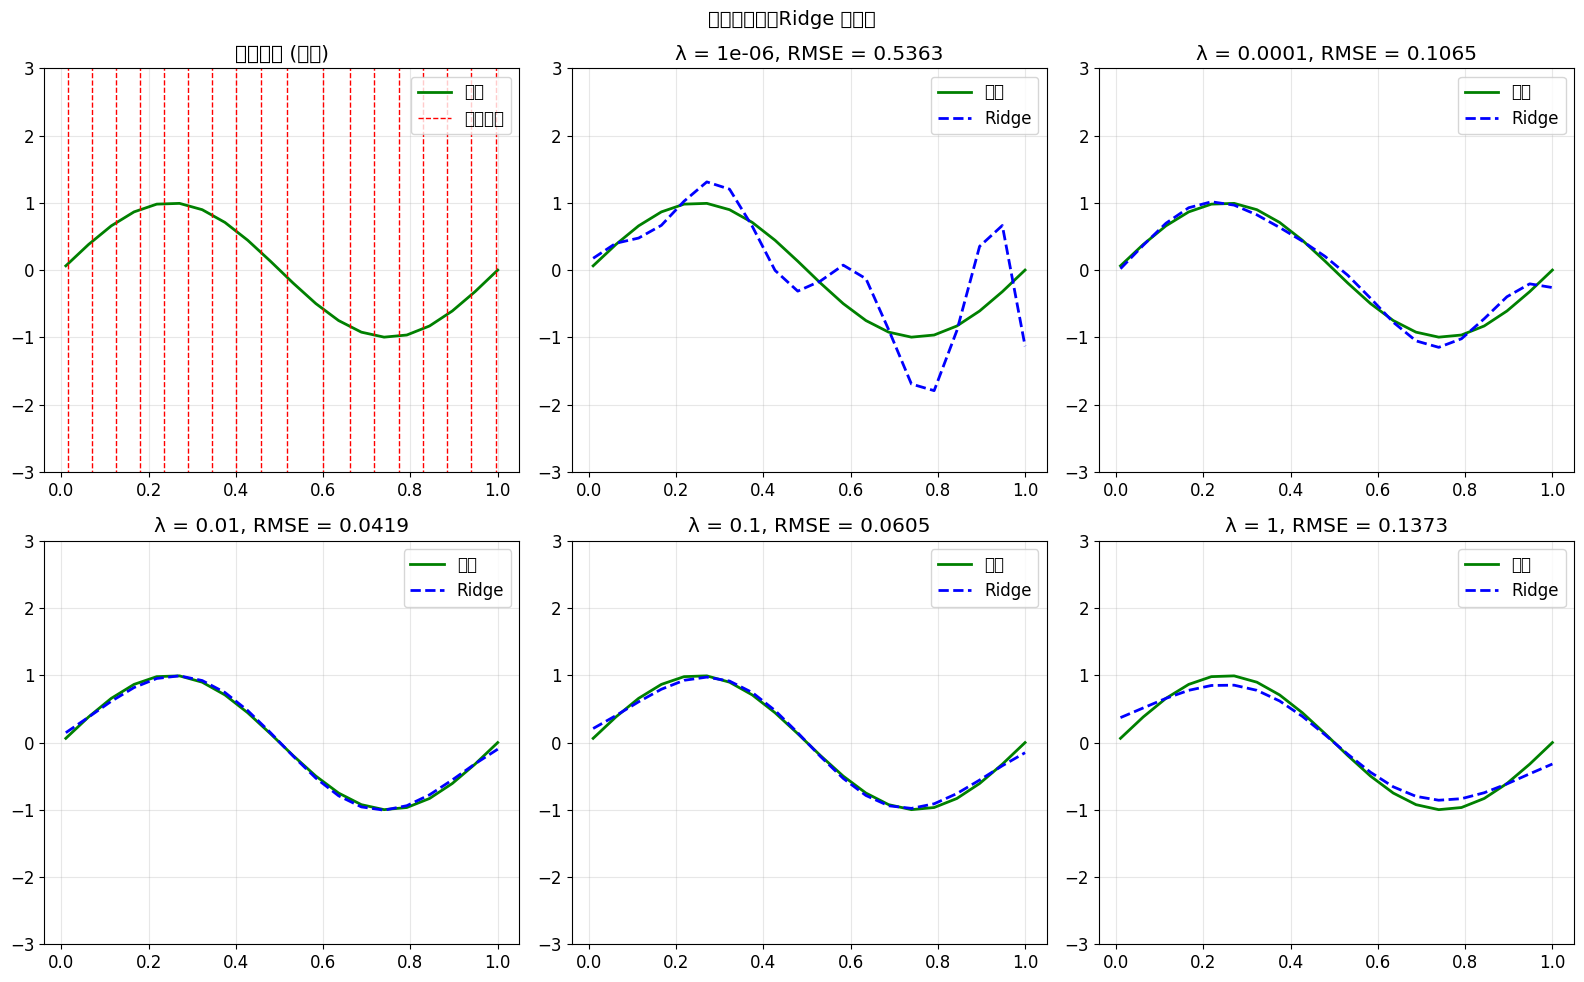

In [5]:
# 逆熱傳問題：已知表面溫度歷史，估計內部熱源
# 建立一個病態的逆問題矩陣
np.random.seed(42)
n = 20
# 模擬熱傳核函數（病態矩陣）
t = np.linspace(0.01, 1, n)
A_heat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A_heat[i, j] = np.exp(-((t[i] - t[j])**2) / 0.1)

# 真實熱源
q_true = np.sin(2 * np.pi * t)
# 量測（含噪聲）
T_measured = A_heat @ q_true + np.random.normal(0, 0.01, n)

cond_num = np.linalg.cond(A_heat)
print(f'矩陣條件數: {cond_num:.1e} (非常病態！)')

# 直接求解（發散）
q_direct = np.linalg.solve(A_heat, T_measured)
print(f'直接求解: max|q| = {np.max(np.abs(q_direct)):.1e} (嚴重發散！)')

# Ridge 正規化
lambdas = [1e-6, 1e-4, 1e-2, 1e-1, 1]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

axes[0].plot(t, q_true, 'g-', lw=2, label='真實')
axes[0].plot(t, q_direct, 'r--', lw=1, label='直接求解')
axes[0].set_title(f'直接求解 (發散)')
axes[0].set_ylim(-3, 3)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for idx, lam in enumerate(lambdas):
    q_ridge = ridge_regression(A_heat, T_measured, lam)
    rmse = np.sqrt(np.mean((q_ridge - q_true)**2))
    axes[idx+1].plot(t, q_true, 'g-', lw=2, label='真實')
    axes[idx+1].plot(t, q_ridge, 'b--', lw=2, label=f'Ridge')
    axes[idx+1].set_title(f'λ = {lam}, RMSE = {rmse:.4f}')
    axes[idx+1].set_ylim(-3, 3)
    axes[idx+1].legend()
    axes[idx+1].grid(True, alpha=0.3)

plt.suptitle('逆熱傳問題：Ridge 正規化', fontsize=14)
plt.tight_layout()
plt.show()

### L-curve 分析：如何選擇最佳的 $\lambda$？

上面的結果顯示，$\lambda$ 太小（如 $10^{-6}$）時，正規化效果不足，解仍然震盪；$\lambda$ 太大（如 $1$）時，解雖然穩定但過度平滑，偏離了真實值。我們需要一個系統化的方法來選擇「剛剛好」的 $\lambda$。

**L-curve 方法：** 對每一個 $\lambda$ 值，我們可以計算兩個量：
1. **殘差大小** $\|A\vec{x} - \vec{b}\|$：衡量解有多「吻合」數據
2. **解的大小** $\|\vec{x}\|$：衡量解有多「平滑/穩定」

把這兩個量畫在 log-log 圖上，通常會得到一條 L 形的曲線：
- L 的水平部分：$\lambda$ 很小，殘差小（吻合數據），但解的範數大（不穩定）
- L 的垂直部分：$\lambda$ 很大，解的範數小（穩定），但殘差大（不吻合數據）
- **L 的拐角處**：就是最佳的 $\lambda$，在「吻合數據」和「穩定解」之間取得最佳平衡

**直覺理解：** 這就像調整音響的音量。音量太小聽不清楚（殘差大），音量太大會有失真和雜音（解不穩定）。L-curve 的拐角就是那個「清楚又不失真」的甜蜜點。

/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/297483956.py:36: UserWarning: Glyph 27544 (\N{CJK UNIFIED IDEOGRAPH-6B98}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/297483956.py:36: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/297483956.py:36: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/297483956.py:36: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6417t7j33gw9b8vh0000gn/T/ipykernel_38532/297483956.py:36: UserWarning: Glyph 31684 (\N{CJK UNIFIED IDEOGRAPH-7BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zf/mg4jlymj6

/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 31684 (\N{CJK UNIFIED IDEOGRAPH-7BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21443 (\N{CJK UNIFIED IDEOGRAPH-53C3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/rexwang/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarni

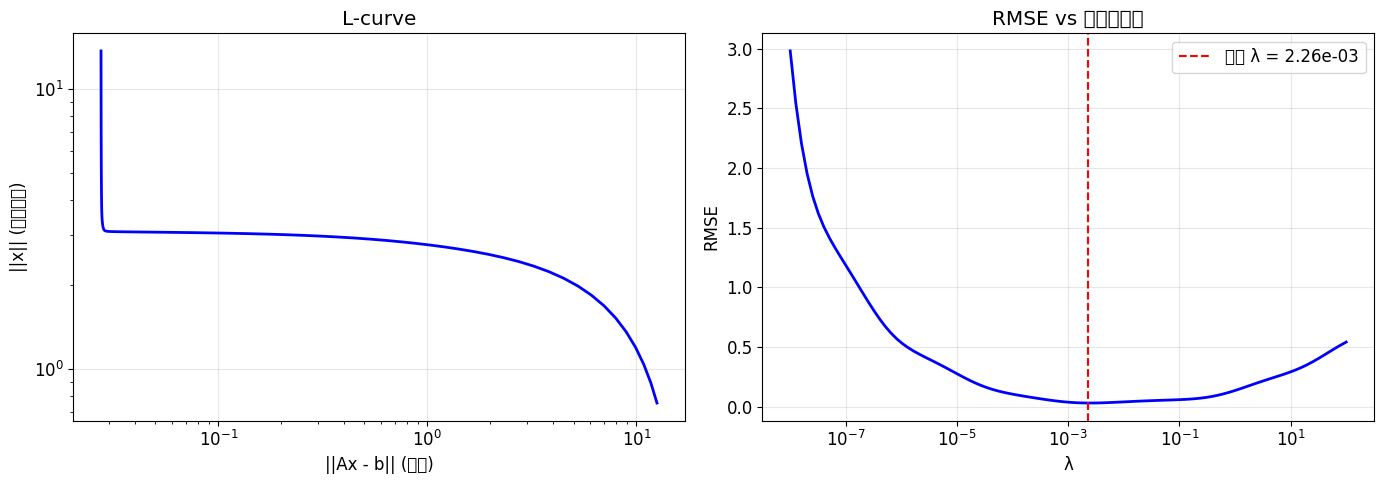

最佳 λ = 2.26e-03, RMSE = 0.0324


In [6]:
# L-curve 分析：選擇最佳 λ
lambdas_scan = np.logspace(-8, 2, 100)
norms_solution = []
norms_residual = []

for lam in lambdas_scan:
    q = ridge_regression(A_heat, T_measured, lam)
    norms_solution.append(np.linalg.norm(q))
    norms_residual.append(np.linalg.norm(A_heat @ q - T_measured))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# L-curve
ax1.loglog(norms_residual, norms_solution, 'b-', lw=2)
ax1.set_xlabel('||Ax - b|| (殘差)')  
ax1.set_ylabel('||x|| (解的範數)')
ax1.set_title('L-curve')
ax1.grid(True, alpha=0.3)

# RMSE vs λ
rmses = []
for lam in lambdas_scan:
    q = ridge_regression(A_heat, T_measured, lam)
    rmses.append(np.sqrt(np.mean((q - q_true)**2)))

best_idx = np.argmin(rmses)
ax2.semilogx(lambdas_scan, rmses, 'b-', lw=2)
ax2.axvline(lambdas_scan[best_idx], color='r', ls='--',
            label=f'最佳 λ = {lambdas_scan[best_idx]:.2e}')
ax2.set_xlabel('λ')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE vs 正規化參數')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'最佳 λ = {lambdas_scan[best_idx]:.2e}, RMSE = {rmses[best_idx]:.4f}')

---
## Module 7 驗證總結

| 項目 | 驗證方式 | 結果 |
|------|----------|------|
| 彈簧常數 | 擬合值 ≈ 真實值 | ✓ |
| Normal Eq vs lstsq | np.allclose | ✓ |
| R² 合理 | 0 < R² ≤ 1 | ✓ |
| Ridge 穩定 | 解不發散 | ✓ |
| L-curve | 最佳 λ 可選 | ✓ |

### 本模組核心觀念回顧

**7.1 線性迴歸的矩陣解：**
- Normal Equation $\hat{\beta} = (X^TX)^{-1}X^T\vec{y}$ 是從數據擬合參數的「萬用公式」
- 幾何意義：將量測向量投影到模型的行空間上
- 適用於任何「對參數線性」的模型（直線、多項式、多元迴歸...）
- $R^2$ 是衡量擬合品質的關鍵指標：越接近 1 越好

**7.2 正規化：**
- 病態問題（高條件數矩陣）會讓雜訊被無限放大
- Ridge Regression 透過加入 $\lambda I$ 來穩定求解
- $\lambda$ 的選擇是「吻合數據」vs「穩定解」的權衡
- L-curve 是選擇最佳 $\lambda$ 的實用工具

### 延伸思考

- **Lasso（L1 正規化）** 使用 $\|\vec{x}\|_1$ 作為懲罰項，可以產生稀疏解（很多參數為零），適合特徵選擇
- **Tikhonov 正規化** 是 Ridge 的推廣形式，可以用不同的矩陣 $L$ 取代 $I$（例如用微分算子來懲罰解的不平滑度）
- **交叉驗證（Cross-validation）** 是在沒有真實解可比較時，選擇 $\lambda$ 的標準方法